In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/OnlineRetail.csv', encoding='latin1')

In [3]:
df.head()
df.shape
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37309 entries, 0 to 37308
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    37309 non-null  object 
 1   StockCode    37309 non-null  object 
 2   Description  37192 non-null  object 
 3   Quantity     37309 non-null  int64  
 4   InvoiceDate  37309 non-null  object 
 5   UnitPrice    37308 non-null  float64
 6   CustomerID   24429 non-null  float64
 7   Country      37308 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 2.3+ MB


In [4]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,117
Quantity,0
InvoiceDate,0
UnitPrice,1
CustomerID,12880
Country,1


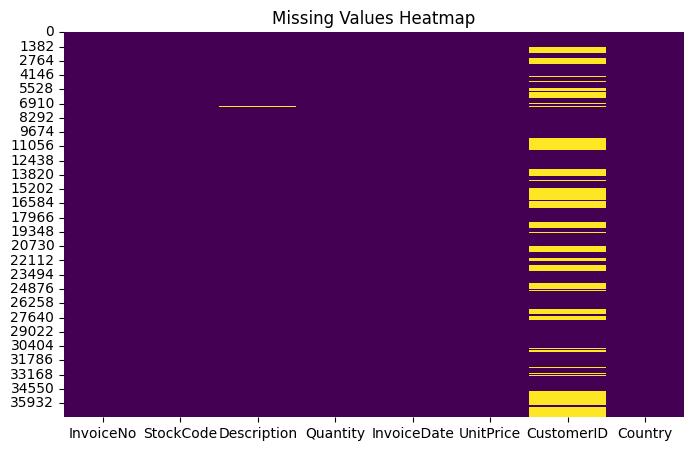

In [5]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap')
plt.show()

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [8]:
df.duplicated().sum()

np.int64(471)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


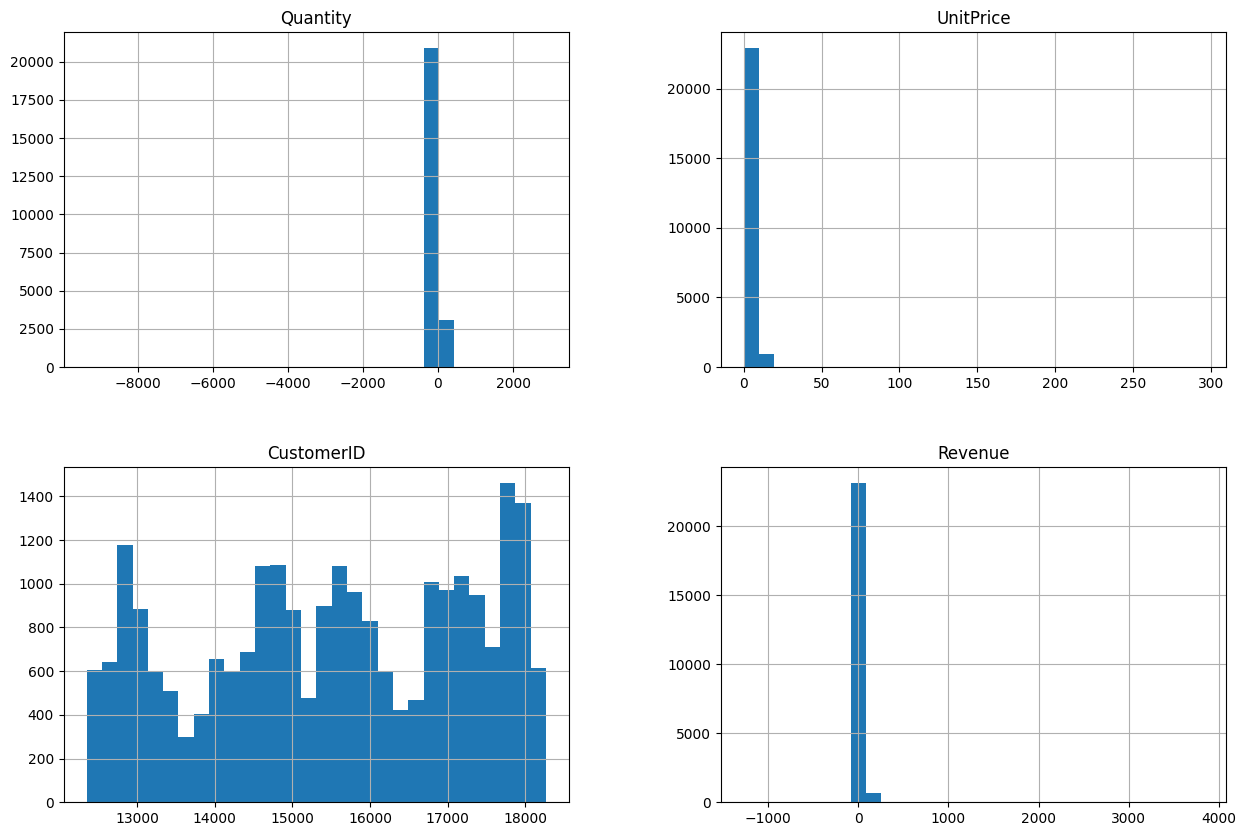

In [12]:
df.hist(
    figsize=(15,10),
    bins=30
)

plt.show()

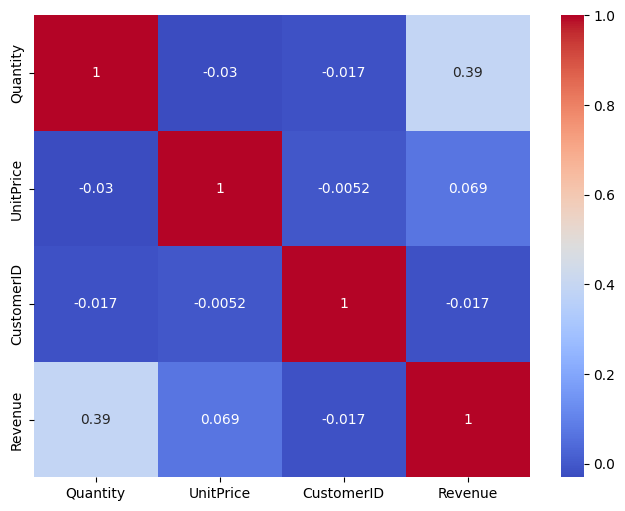

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

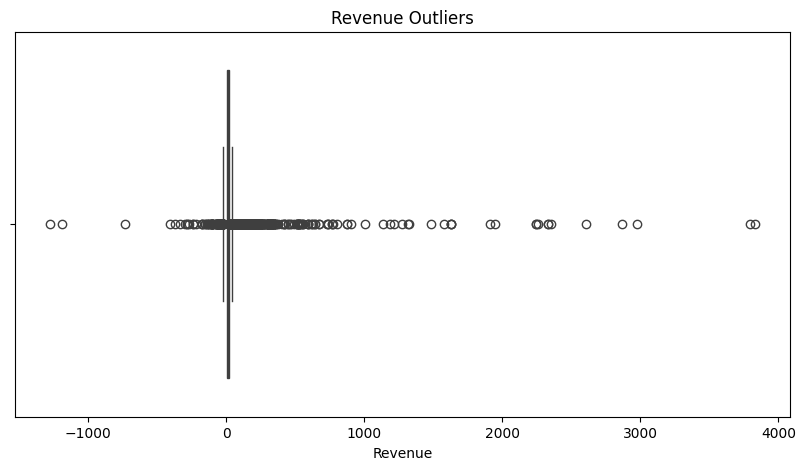

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Revenue']
)

plt.title('Revenue Outliers')
plt.show()

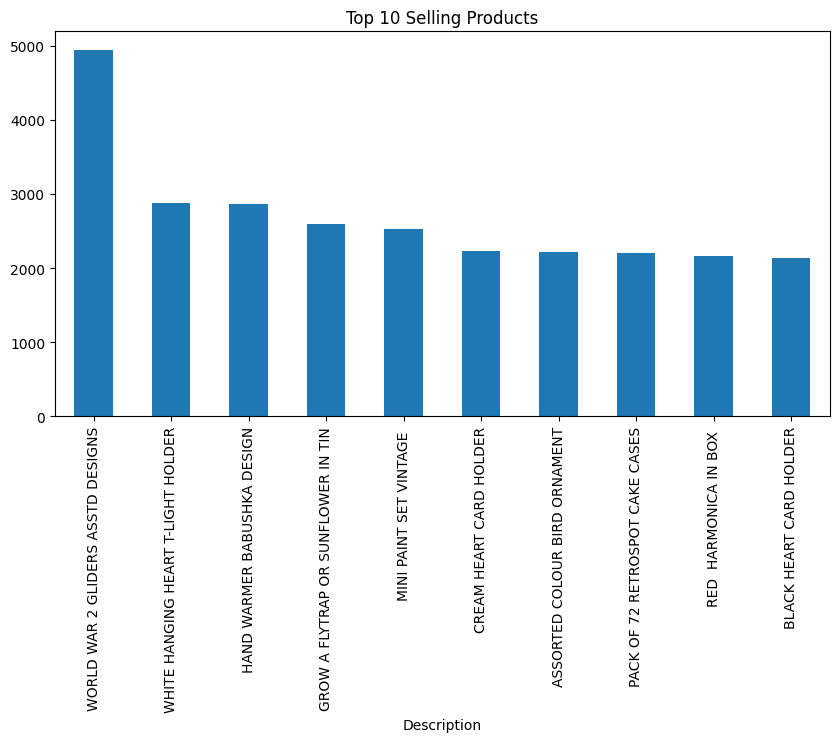

In [15]:
#Top Selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.show()

In [17]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

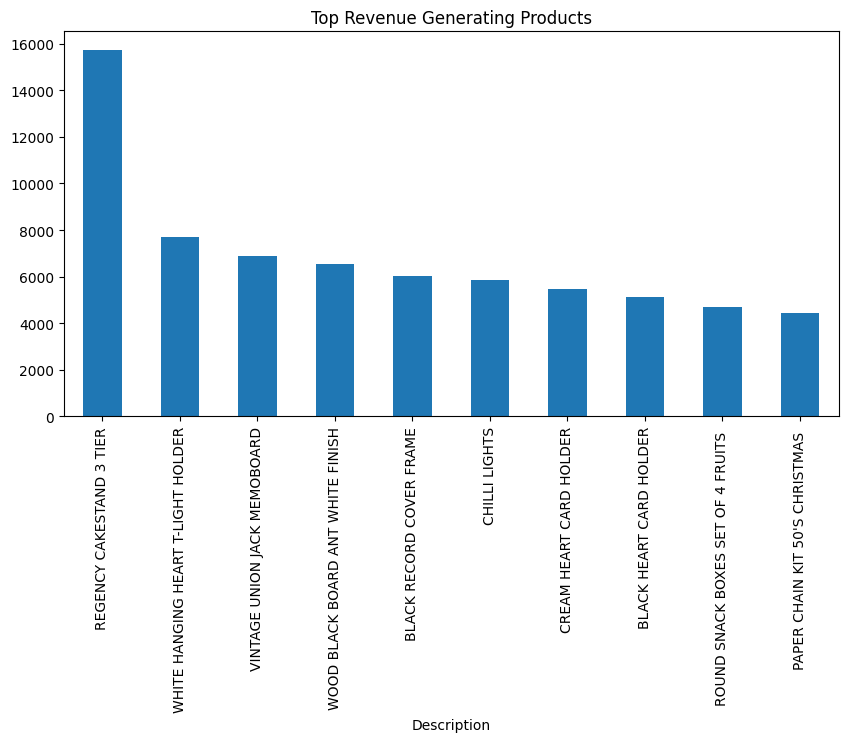

In [18]:
# top revenue product
top_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_revenue.plot(kind='bar')
plt.title('Top Revenue Generating Products')
plt.show()

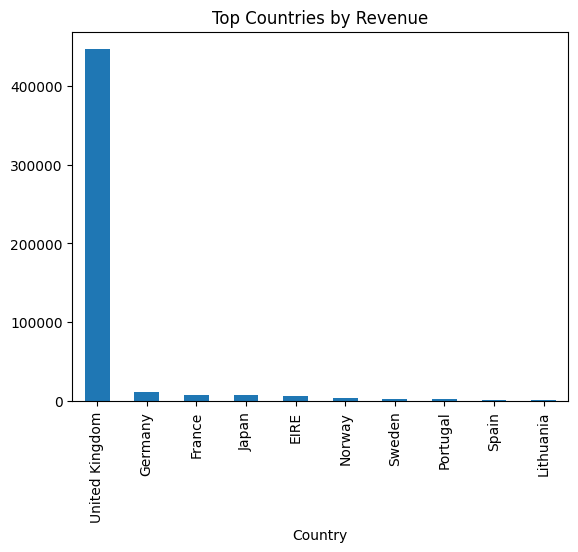

In [19]:
#top purchase countrywise
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.show()

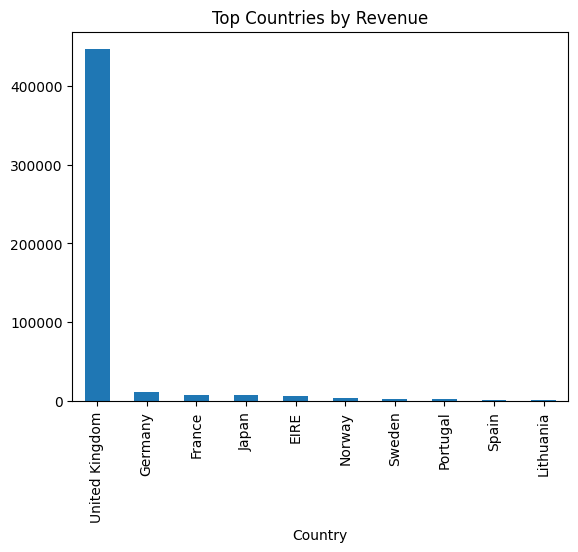

In [20]:
#Monthly Sales
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.show()

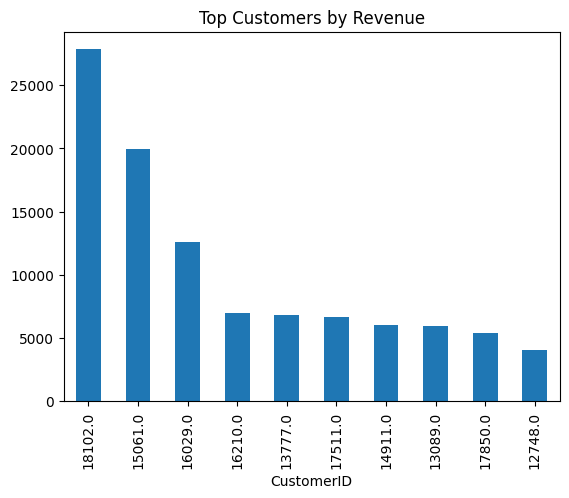

In [21]:
# valuble customer
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title('Top Customers by Revenue')
plt.show()

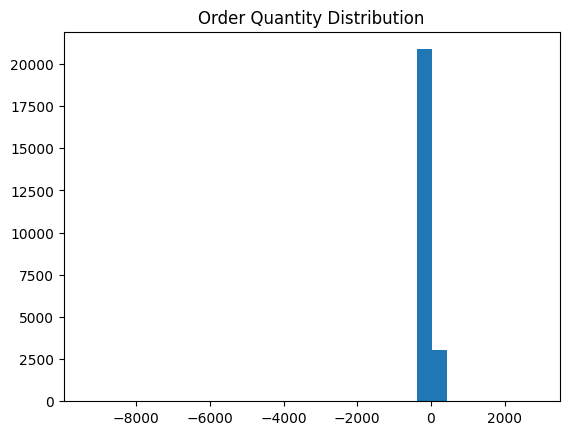

In [22]:
plt.hist(df['Quantity'],bins=30)
plt.title('Order Quantity Distribution')
plt.show()

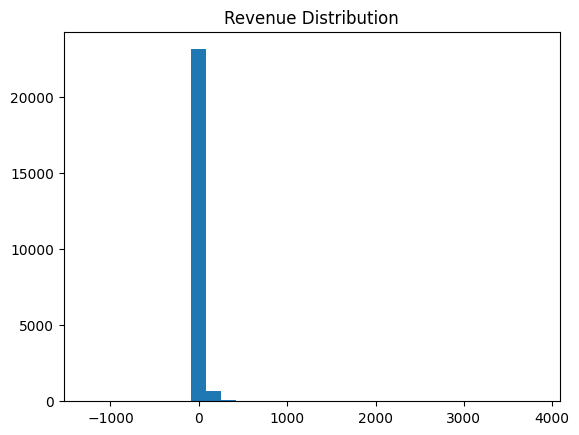

In [23]:
# show revenue
plt.hist(df['Revenue'],bins=30)
plt.title('Revenue Distribution')
plt.show()

In [24]:
# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [26]:
# Customer-wise summary
customer_data = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'Quantity':'sum'
})

customer_data.columns = [
    'Revenue',
    'Orders',
    'Quantity'
]

customer_data.head()

,Revenue,Orders,Quantity
CustomerID,,,
12347.0,711.79,1,319
12348.0,892.80,1,1254
12370.0,1864.27,2,967
12386.0,258.90,1,214
12395.0,679.92,2,753


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_data['Cluster'] = kmeans.fit_predict(
    scaled_data
)

In [29]:
customer_data['Cluster'].value_counts()

,count
Cluster,
0,857
1,36
3,3
2,2


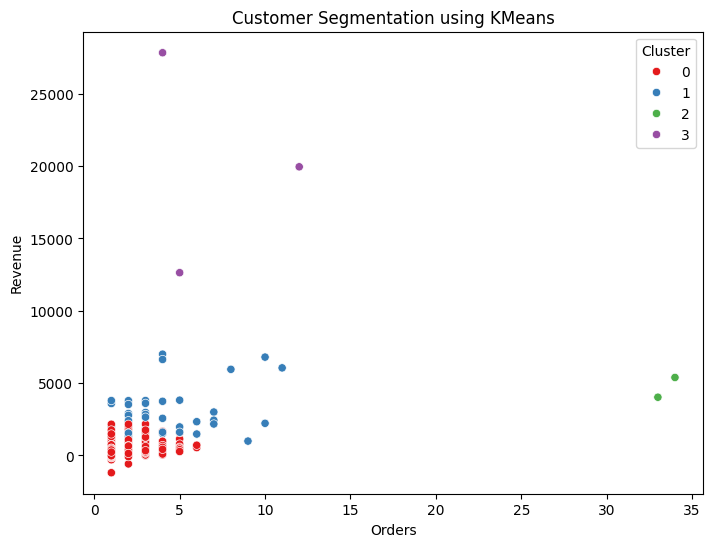

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Orders',
    y='Revenue',
    hue='Cluster',
    data=customer_data,
    palette='Set1'
)

plt.title('Customer Segmentation using KMeans')

plt.show()